# Parse Dictionary

In [1]:
import pandas as pd
import numpy as np

In [2]:
GLOSS = pd.DataFrame(open("quidic_complete.txt", "r").readlines(), columns=['line_str']).iloc[233:]
GLOSS['term_str'] = GLOSS.line_str.str.split("\(").str[0].str.strip().str.replace("’", "'")
GLOSS['term_def_raw'] = GLOSS.line_str.str.split("\(").str[1:].apply(" ".join).str.strip()
GLOSS = GLOSS[GLOSS.term_def_raw != ''].copy()
GLOSS['pos'] = GLOSS.term_def_raw.str.split("\)").str[0]
GLOSS['term_def'] = GLOSS.term_def_raw.str.split("\)").str[1:].apply(" ".join).str.strip()
GLOSS = GLOSS.drop(['line_str', 'term_def_raw'], axis=1)
GLOSS.index.name = 'gloss_id'

In [3]:
# GLOSS.pos.value_counts()

In [4]:
GLOSS[GLOSS.term_str.str.match(r"^ta$")]

,term_str,pos,term_def
gloss_id,,,
5849,ta,v,to understand; to hear


In [5]:
GLOSS.loc[GLOSS.term_str.str.match("^ya'$")]

,term_str,pos,term_def
gloss_id,,,
7538,ya',v,to give; to place; to allow; to be possible


In [6]:
V = GLOSS.term_str.value_counts().to_frame('n')

In [7]:
V[V.isna()] # WTF

,n
term_str,
qaj,NaN
kieb -wäch,NaN
tzalanik,NaN
xaq,NaN
aj,NaN
...,...
k'ulanem,NaN
k'ulan<ik>,NaN
k'uläm,NaN


In [117]:
def look_up(my_str):
    return GLOSS.loc[GLOSS.term_str.str.lower().str.match(my_str)]

In [155]:
def look_up_substr(my_substr, as_set=False):
    r = GLOSS.loc[GLOSS.term_str.str.lower().str.contains(my_substr)]
    if as_set:
        return set(r.term_str.to_list())
    else:
        return r

In [152]:
look_up_substr("min", True)

["-baq'wäch käminaq",
 'jaminik',
 '-jolom käminak',
 '-jul käminaq',
 'käminaq',
 'käminaq',
 "käminäq ri ik'",
 'kolominaj be',
 "loq'ominel",
 'min',
 'mine',
 'relewal käminaq',
 'tumin',
 'xuminik']

In [144]:
look_up("^mi")

,term_str,pos,term_def
gloss_id,,,
3735,mial<axel>,n,daughter of a male
3736,mialabal<axel>,n,"daughter-in-law; god-daughter, niece of man"
3737,mich,n,tz’ite beans
3738,mich',n,weeding
3740,mich'<o>,tv1,"to weed especially wheat field , to pluck hair"
3741,mich'mitik,v,eat plants rabbit or other animal
3742,mich'onik,v,to weed wheat field
3743,mier,adv,earlier today; a while ago
3744,min,v,"to force, to cram into; to put in"


In [145]:
look_up("^tz'i'$")

,term_str,pos,term_def
gloss_id,,,
6410,tz'i',adj,foolish; disobedient child
6411,Tz'i',n,day in the sacred calendar
6412,tz'i',n,dog


In [146]:
look_up("tz")

,term_str,pos,term_def
gloss_id,,,
6362,tz'a'r,n,quince membrillo fruit
6363,tz'abej,v,to give in excess
6364,tz'abel,n,excess; overflow
6365,tz'abem,adj,abundant
6366,tz'aj<o>,v,to stain; to dye; to paint
...,...,...,...
6731,tzurunik,v,to dare; challenge; to molest; harass; to flir...
6732,tzururik,v,to have luster
6733,tzuruw ri wakax,v,to fight bull


# Words with $z$ but not $tz$

In [156]:
look_up_substr('z', True) - look_up_substr('tz', True)

{'Kzal', 'arroz', 'azete'}

# Words with $v$

In [157]:
look_up_substr('v')

,term_str,pos,term_def
gloss_id,,,
1027,ch'ämalaj vino,n,vinager
4533,pitz'bal uvas,n,wine press


In [158]:
xim_term = 'vbac'.replace('v','').replace('c','q\'')

In [159]:
xim_term

"baq'"

In [160]:
look_up(xim_term)

,term_str,pos,term_def
gloss_id,,,
749,baq',n,seed; pit; stone fruit
753,baq'atij,v,"to roll up; to twist wire, neck of a chicken"
754,baq'atij -ib,v,to become entangled
755,baq'atim,adj,rolled up; twisted
756,baq'ek,v,to become bored
757,baq'otik,v,to walk like a drunk; to stagger from illness
758,baq'wäch,n,eye
761,baq'wäch triko,n,grain of wheat


In [161]:
look_up_substr(xim_term)

,term_str,pos,term_def
gloss_id,,,
273,achij -baq'wäch,n,polygamous husband
749,baq',n,seed; pit; stone fruit
750,-baq' kampana,n,bell striker
751,-baq' q'aq',n,bullet
752,-baq' winaq,n,evil eye
753,baq'atij,v,"to roll up; to twist wire, neck of a chicken"
754,baq'atij -ib,v,to become entangled
755,baq'atim,adj,rolled up; twisted
756,baq'ek,v,to become bored


In [162]:
look_up("u")

,term_str,pos,term_def
gloss_id,,,
6739,u,poss pro,"his, hers, its"
6740,ubelej,adj,ninth
6741,ubelejlajuj,num,nineteenth
6742,uben,n,tamale equal parts corn and beans eaten just...
6743,ubik,adv,away from speaker
...,...,...,...
6863,uxlanibal k'uxaj,n,peace of the soul; peace of mind
6864,uxlanik,v,to rest
6865,uxlaninaq,adj,tranquil; at rest; in repose


In [170]:
look_up_substr(r"^baq'?$")

,term_str,pos,term_def
gloss_id,,,
745,baq,adj,thin; skinny
746,baq,n,bone; needle
747,baq,v,"to wash hair, face"
749,baq',n,seed; pit; stone fruit


In [171]:
look_up_substr('baq')

,term_str,pos,term_def
gloss_id,,,
273,achij -baq'wäch,n,polygamous husband
745,baq,adj,thin; skinny
746,baq,n,bone; needle
747,baq,v,"to wash hair, face"
748,baq chikop,n,gusano alambre worm that eats planted corn seed
749,baq',n,seed; pit; stone fruit
750,-baq' kampana,n,bell striker
751,-baq' q'aq',n,bullet
752,-baq' winaq,n,evil eye


In [76]:
look_up("abix")

,term_str,pos,term_def
gloss_id,,,
248,abix,n,corn plant; cornfield
249,abixbal,n,plow
250,abixik,v,to plow
251,abixinik,v,to cultivate a plot of land


In [82]:
set(look_up_substr('c')) - set(look_up_substr('ch'))

{"-ki'<al> cumätz", "nik'aj cient", 'racakik', "toq'inel alcabal"}

# Pronunciation Guide

In [198]:
GUIDE = pd.read_csv("Glossary_Table.csv")
GUIDE.index.name = 'entry_id'
GUIDE.columns = ['parra', 'modern', 'desc']

In [199]:
GUIDE

,parra,modern,desc
entry_id,,,
0,"a, aa",a,As in the 'a' of 'father.'
1,a,ä,As in the 'o' of 'mother.'
2,b,b',"Similar to the English 'b', but pronounced wit..."
3,ch,ch,As in the 'ch' of 'child.'
4,"qh, ch",ch',Pronounced with the tongue in the same positio...
5,"e, ee",e,As in the 'a' of 'late.'
6,"i, ÿ, ii",i,As in the 'ee' in 'eel.'
7,h,j,"Pronounced like the English 'h', but deeper in..."
8,"c, q",k,Similar to the 'k' in 'king.'


In [220]:
GUIDE2 = GUIDE.parra.apply(lambda x: x.split(",")).apply(pd.Series).stack().to_frame("parra")
GUIDE2.index.names = ['entry_id', 'sub_id']
GUIDE2 = GUIDE2.join(GUIDE[['modern','desc']], on='entry_id')
GUIDE2 = GUIDE2.set_index(['parra','modern'])

In [223]:
GUIDE2.sort_values('modern')

,,desc
parra,modern,
',',"Glottalization mark for vowels. For example, '..."
a,a,As in the 'a' of 'father.'
aa,a,As in the 'a' of 'father.'
b,b',"Similar to the English 'b', but pronounced wit..."
ch,ch,As in the 'ch' of 'child.'
qh,ch',Pronounced with the tongue in the same positio...
ch,ch',Pronounced with the tongue in the same positio...
e,e,As in the 'a' of 'late.'
ee,e,As in the 'a' of 'late.'


In [248]:
GUIDE2.loc["y"]

,desc
modern,
y,As in the 'y' of 'yellow.' When appearing as t...


In [228]:
GM = GUIDE2.unstack(fill_value='').astype(bool).astype(int)

In [236]:
GM.columns = GM.columns.droplevel(0)

In [246]:
GM["q'"]

parra
 aa    0
 c     1
 ch    0
 ee    0
 i     0
 ii    0
 oo    0
 q     1
 t     0
 u     0
 uu    0
 v     0
 ÿ     0
'      0
a      0
b      0
c      0
ch     0
d      0
e      0
h      0
i      0
l      0
m      0
n      0
o      0
p      0
qh     0
r      0
t      0
tz     0
u      0
v      0
x      0
y      0
z      0
ε      1
Name: q', dtype: int64

In [244]:
CHAR = GM.sum().sort_values().to_frame('n_parra')

In [245]:
CHAR

,n_parra
modern,
',1
b',1
ch,1
j,1
n,1
p,1
l,1
m,1
tz,1


# Pronunciation

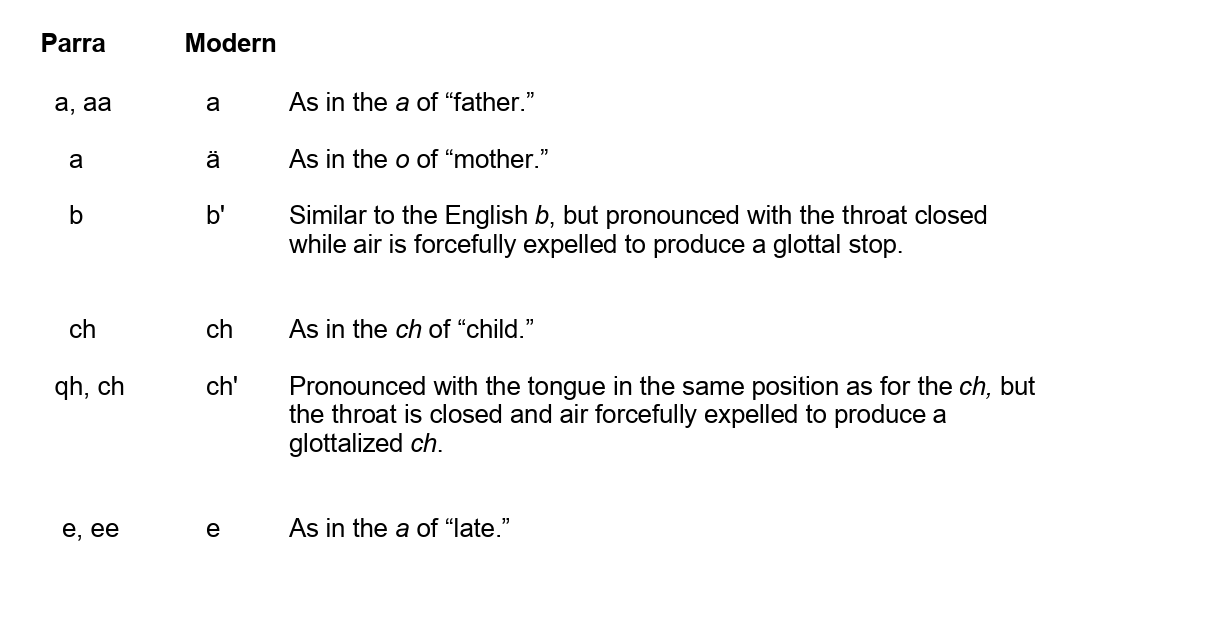

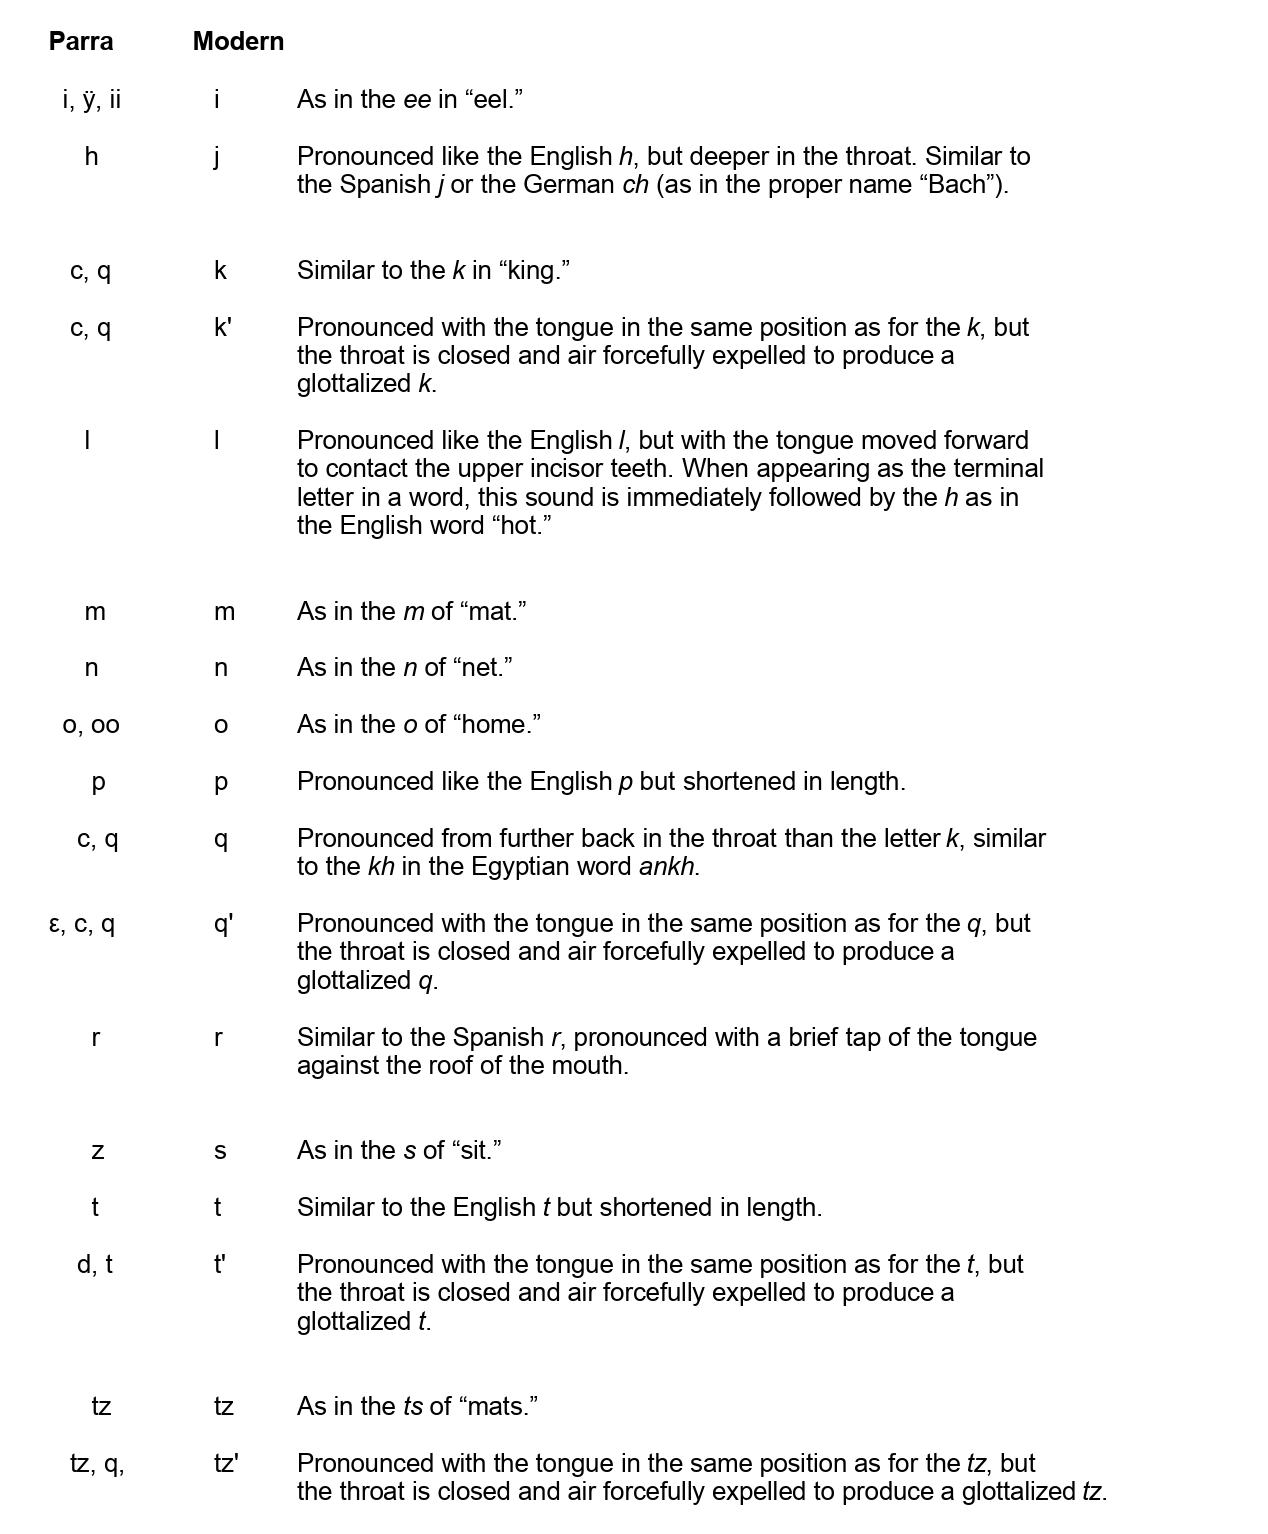

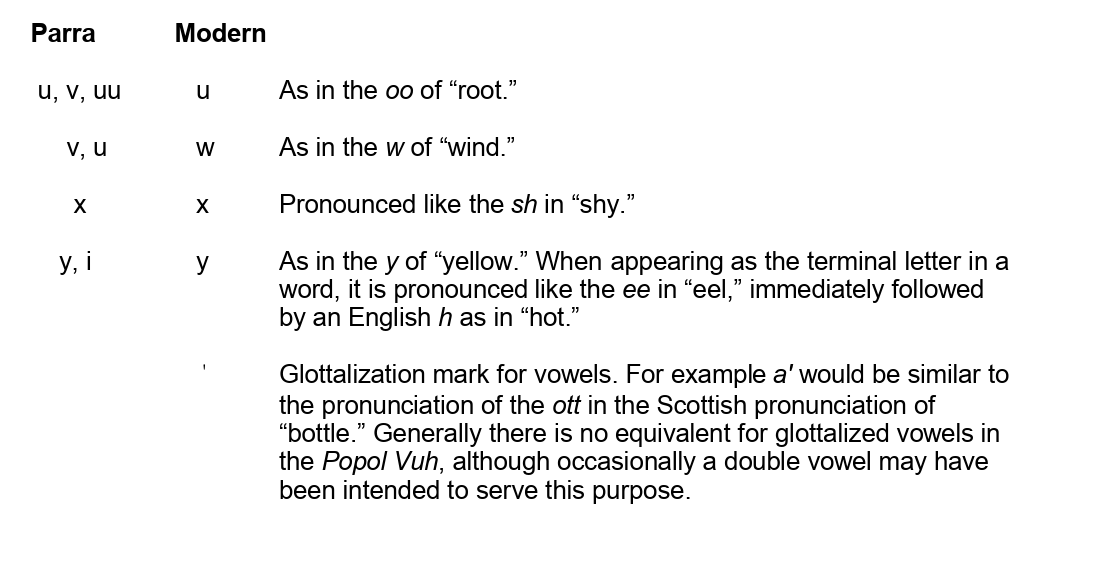